# 01 · Data exploration

What the Sentinel-1 archive over the Kazipur–Chauhali reach looks like: how many passes, how regular, and what the radar sees.

In [1]:
import sys, json
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from src import config
M = config.METRICS_DIR
def load(name):
    p = M / f"{name}.json"
    return json.loads(p.read_text()) if p.exists() else None
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": "#e1e0d9", "axes.edgecolor": "#c3c2b7"})
C1, C2, C3 = "#2a78d6", "#eb6834", "#1baf7a"


In [2]:
cat = json.loads((config.PROCESSED / "s1_catalog.json").read_text())
passes = pd.DataFrame([dict(pass_id=p["pass_id"], date=pd.Timestamp(p["date"]), platform=p["platform"], slices=len(p["slices"])) for p in cat])
print(len(passes), "passes of relative orbit", config.S1_RELATIVE_ORBIT, passes.date.min().date(), "→", passes.date.max().date())
passes.groupby([passes.date.dt.year, "platform"]).size().unstack(fill_value=0)

271 passes of relative orbit 150 2015-01-19 → 2025-12-28


platform,S1A,S1B
date,,
2015,10,0
2016,13,0
2017,24,0
2018,28,0
2019,28,1
2020,31,2
2021,30,0
2022,28,0
2023,25,0


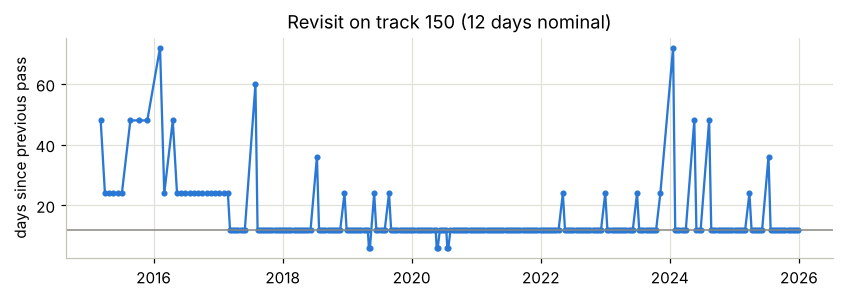

,date,gap_days
1,2015-03-08,48.0
7,2015-08-23,48.0
8,2015-10-10,48.0
9,2015-11-27,48.0
10,2016-02-07,72.0
12,2016-04-19,48.0
34,2017-07-31,60.0
61,2018-07-14,36.0
220,2024-01-20,72.0
227,2024-05-19,48.0


In [3]:
gaps = passes.date.diff().dt.days
fig, ax = plt.subplots(figsize=(9, 2.6))
ax.plot(passes.date, gaps, color=C1, lw=1.5, marker="o", ms=3)
ax.axhline(12, color="#898781", lw=1)
ax.set_ylabel("days since previous pass"); ax.set_title("Revisit on track 150 (12 days nominal)")
plt.show()
passes.loc[gaps > 24, ["date"]].assign(gap_days=gaps[gaps > 24])

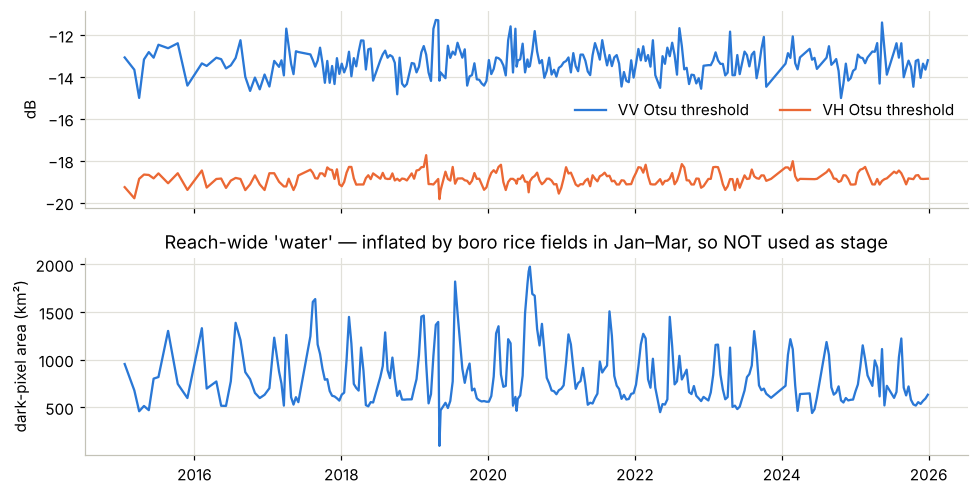

Otsu outside plausible range on 1 of 271 passes


In [4]:
s = pd.read_csv(config.MASK_DIR / "mask_summary.csv", parse_dates=["date"])
fig, axes = plt.subplots(2, 1, figsize=(9, 4.6), sharex=True)
axes[0].plot(s.date, s.t_vv, color=C1, lw=1.5, label="VV Otsu threshold")
axes[0].plot(s.date, s.t_vh, color=C2, lw=1.5, label="VH Otsu threshold")
axes[0].set_ylabel("dB"); axes[0].legend(frameon=False, ncol=2)
axes[1].plot(s.date, s.water_area_km2, color=C1, lw=1.5)
axes[1].set_ylabel("dark-pixel area (km²)")
axes[1].set_title("Reach-wide 'water' — inflated by boro rice fields in Jan–Mar, so NOT used as stage")
plt.tight_layout(); plt.show()
print("Otsu outside plausible range on", int((~s.otsu_ok).sum()), "of", len(s), "passes")

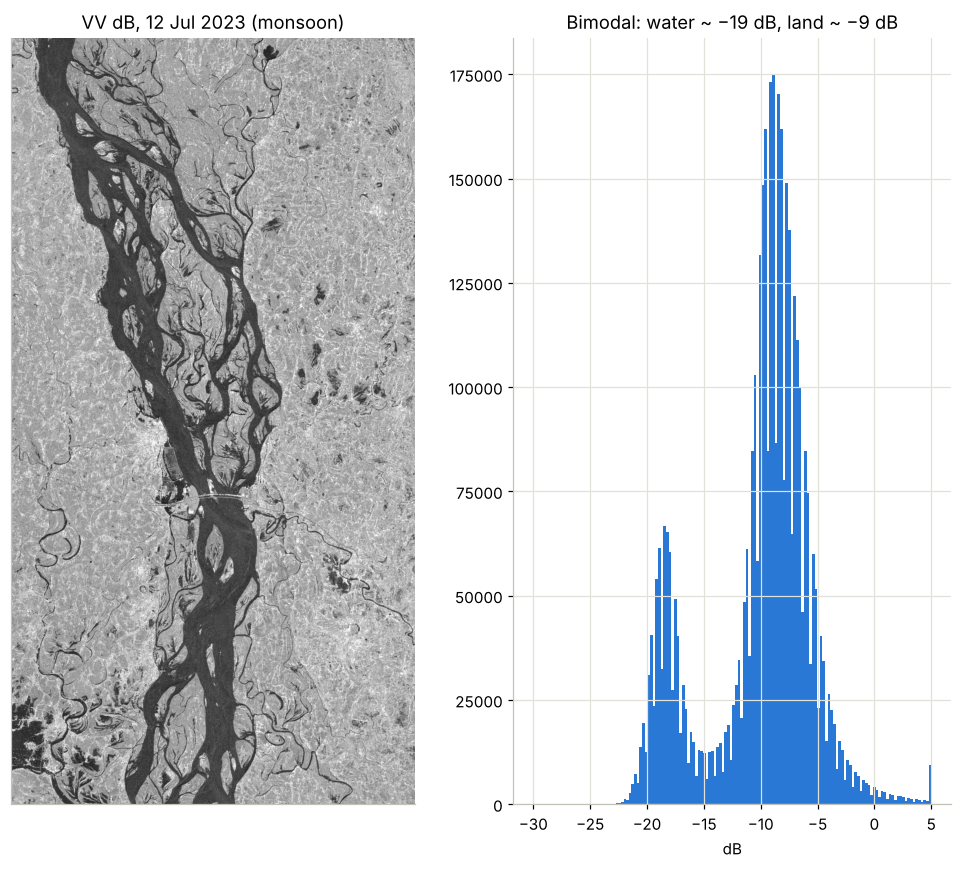

In [5]:
from src.masks.s1_io import read_pass_db
p = config.S1_RAW / "S1_20230712_S1A_r150.tif"
if p.exists():
    vv, vh, tags = read_pass_db(p)
    fig, ax = plt.subplots(1, 2, figsize=(9, 8))
    ax[0].imshow(vv[::4, ::4], cmap="gray", vmin=-25, vmax=0); ax[0].set_title("VV dB, 12 Jul 2023 (monsoon)")
    ax[1].hist(vv[::3, ::3].ravel(), bins=150, range=(-30, 5), color=C1)
    ax[1].set_title("Bimodal: water ~ −19 dB, land ~ −9 dB"); ax[1].set_xlabel("dB")
    for a in ax[:1]: a.set_xticks([]); a.set_yticks([])
    plt.tight_layout(); plt.show()
else:
    print("radar cache not present in this checkout (data/raw is regenerable: scripts/download_data.sh)")